## 1. Autoencoder Optuna + Stochastic + Regularization + Dropout + Early Stopping (Private Score)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, losses
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.metrics import roc_auc_score

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dev_set = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_set = excluded_train_df.groupby('lettr').apply(lambda x: x.sample

Train: (3402, 16)
Val: (378, 16)
Dev: (520, 16)
Test: (1000, 16)
Entire (UCI test): (15757, 16)


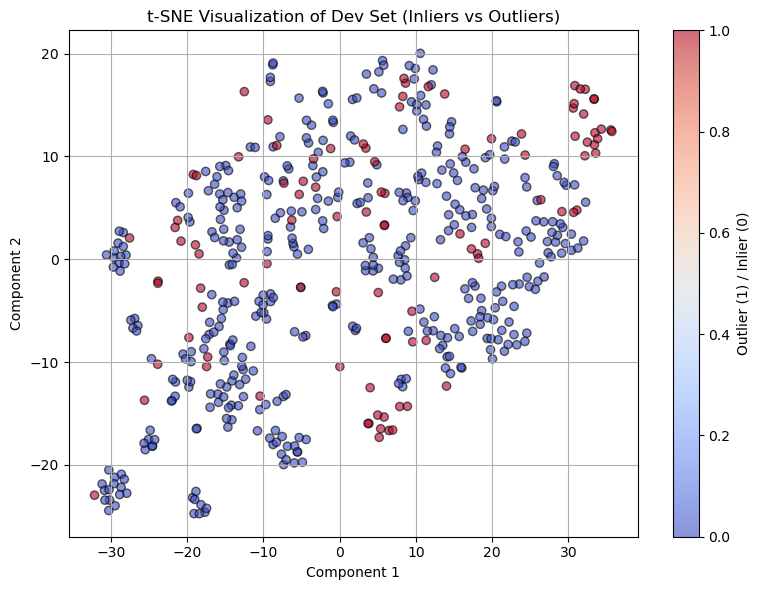

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


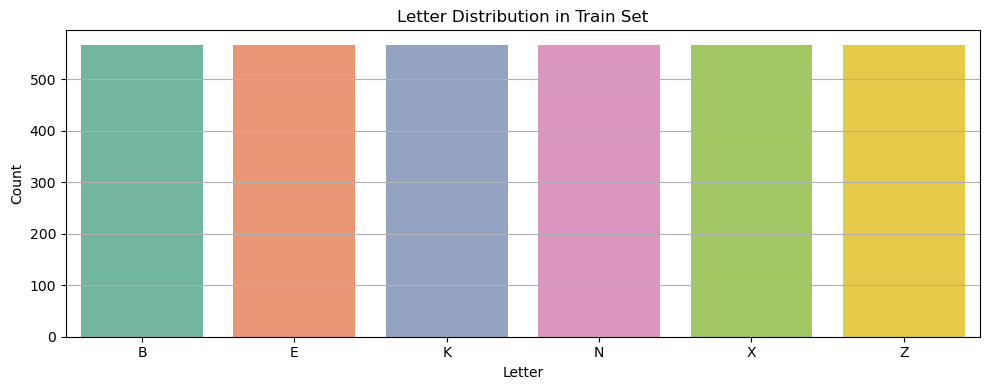

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


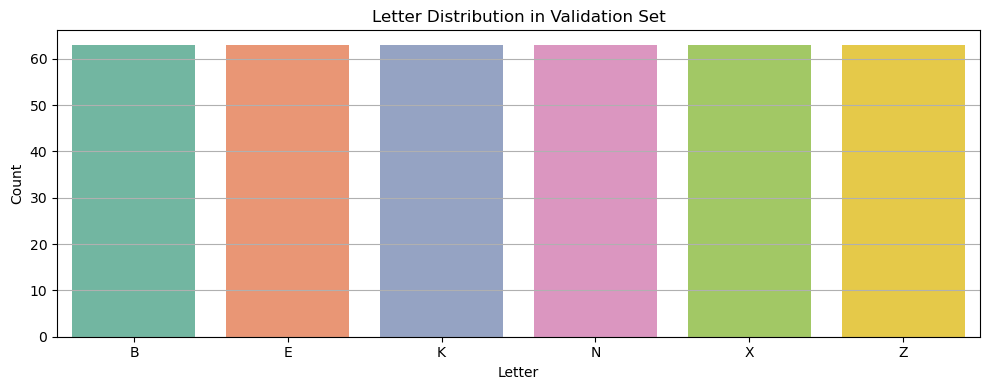

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


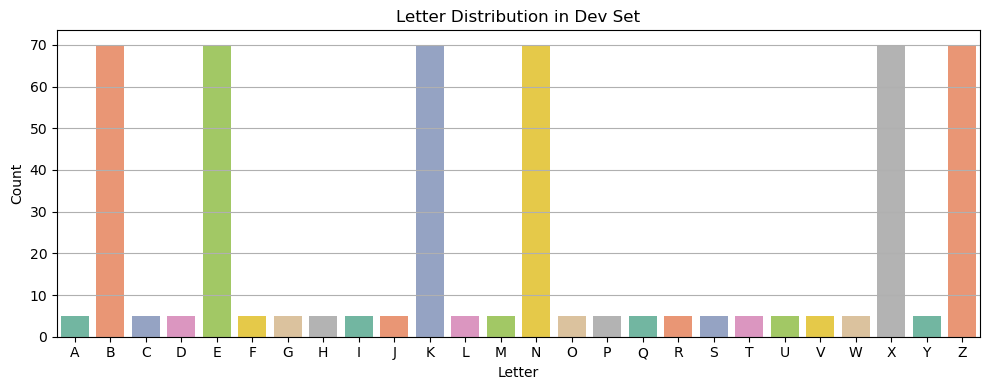

C:\Users\jarvis\AppData\Local\Temp\ipykernel_23696\2842630882.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)


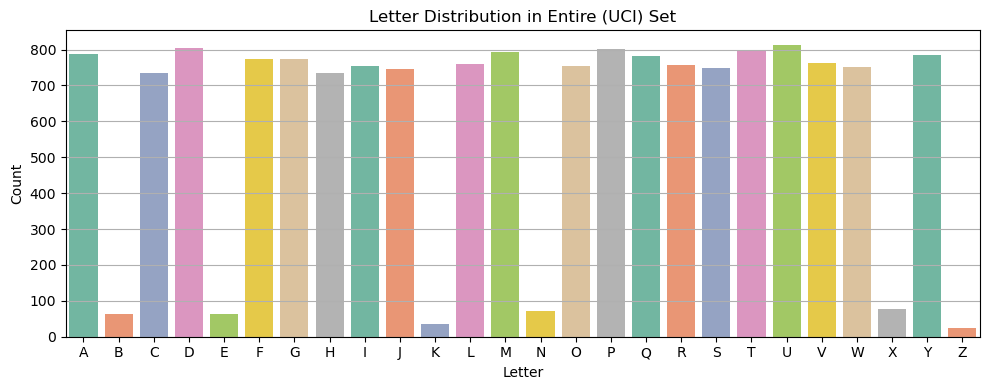

In [21]:
# Configuration
SEED = 42

# Data preprocessing
INLIERS = ['B', 'E', 'K', 'N', 'X', 'Z']

# load data
train_df = pd.read_csv("training.csv")
test_df = pd.read_csv("test_X.csv")
entire_df = pd.read_csv("entire_excluded_training.csv")

# build dev set --> checking overfitting
n_classes = len(train_df["lettr"].unique())
row_per_class = int((len(train_df) * 0.1) // n_classes)
dev_set = train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
dev_set = dev_set.reset_index(level=0, drop=True)
excluded_train_df = train_df.drop(index=dev_set.index).reset_index(drop=True)
dev_set = dev_set.reset_index(drop=True)

# build validation set --> enhance model while running
row_per_class = int((len(excluded_train_df) * 0.1) // n_classes)
val_set = excluded_train_df.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class), random_state=SEED))
val_set = val_set.reset_index(level=0, drop=True)
excluded_train_df = excluded_train_df.drop(index=val_set.index).reset_index(drop=True)
val_set = val_set.reset_index(drop=True)

# ======================
# Label outliers in dev set and entire set
# ======================
entire_df["is_outlier"] = ~entire_df["lettr"].isin(INLIERS)
# add more 50 rows include outliers for dev-set --> no need to exclude they from entire set because we are not training on them
outlier_rows = entire_df[~entire_df["lettr"].isin(INLIERS)]
n_classes_entire = len(entire_df["lettr"].unique()) - len(train_df["lettr"].unique())
row_per_class_entire = int(100 // n_classes_entire)
outlier_part = outlier_rows.groupby('lettr').apply(lambda x: x.sample(n=min(len(x), row_per_class_entire), random_state=SEED)).reset_index(drop=True)
dev_set = pd.concat([dev_set, outlier_part], ignore_index=True)
dev_set["is_outlier"] = ~dev_set["lettr"].isin(INLIERS)


y_dev_true = dev_set["is_outlier"].astype(int).values
y_true_entire = entire_df["is_outlier"].astype(int).values

# ======================
# Split features (X) and remove labels
# ======================
X_train_full = excluded_train_df.drop(columns='lettr')
X_val = val_set.drop(columns='lettr')
X_dev = dev_set.drop(columns=['lettr', 'is_outlier'])
X_test = test_df.copy()
X_entire = entire_df.drop(columns=['lettr', 'is_outlier'])

# ======================
# Feature Scaling
# ======================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_val_scaled = scaler.transform(X_val)
X_dev_scaled = scaler.transform(X_dev)
X_test_scaled = scaler.transform(X_test)
X_entire_scaled = scaler.transform(X_entire)

# ======================
# Shapes for sanity check
# ======================
print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Dev:", X_dev_scaled.shape)
print("Test:", X_test_scaled.shape)
print("Entire (UCI test):", X_entire_scaled.shape)

# ======================
# Visualize data with low dimension and another chart for distributions all of them
# ======================
# Combine dev set with inlier/outlier labels
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED)
X_embedded = tsne.fit_transform(X_dev_scaled)

# Plot 2D t-SNE result
plt.figure(figsize=(8, 6))
plt.scatter(
    X_embedded[:, 0], X_embedded[:, 1],
    c=y_dev_true, cmap='coolwarm', alpha=0.6, edgecolors='k'
)
plt.title("t-SNE Visualization of Dev Set (Inliers vs Outliers)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Outlier (1) / Inlier (0)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ==========================
# Function to plot bar chart
# ==========================
def plot_letter_distribution(df, title, label_column='lettr', figsize=(10, 4), palette='Set2'):
    letter_counts = df[label_column].value_counts().sort_index()
    plt.figure(figsize=figsize)
    sns.barplot(x=letter_counts.index, y=letter_counts.values, palette=palette)
    plt.title(title)
    plt.xlabel("Letter")
    plt.ylabel("Count")
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# ==========================
# Plot distributions
# ==========================
plot_letter_distribution(excluded_train_df, "Letter Distribution in Train Set")
plot_letter_distribution(val_set, "Letter Distribution in Validation Set")
plot_letter_distribution(dev_set, "Letter Distribution in Dev Set")
plot_letter_distribution(entire_df, "Letter Distribution in Entire (UCI) Set")



🔁 Training model 1/4 with seed 42


d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
d:\Softwares\anaconda3\envs\tensorflow\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(



🔁 Training model 2/4 with seed 52

🔁 Training model 3/4 with seed 62

🔁 Training model 4/4 with seed 72


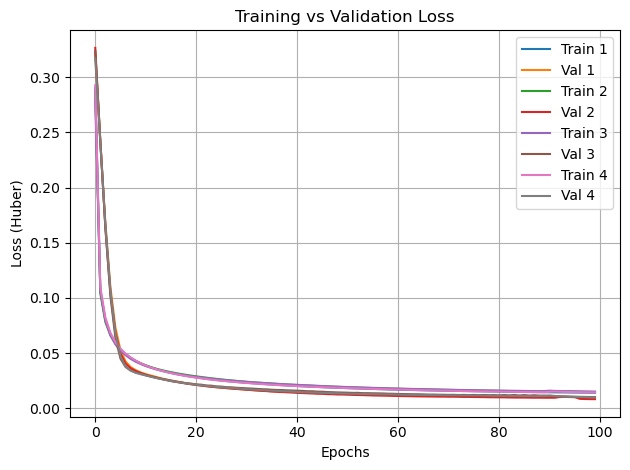


📉 Average minimum validation loss per model: 0.009746
🧪 Mean Test Reconstruction MSE: 0.062049
🧪 AUC on Dev Set: 0.9533
📦 AUC on Entire UCI Set: 0.9544

✅ solution_1_submission_1_auc_.csv saved successfully!


In [22]:
# ========== Train/Validation Split ==========
X_train = X_train_scaled
X_val = X_val_scaled

# ========== Build Autoencoder ==========
def build_autoencoder(input_dim):
    model = models.Sequential([
        layers.Dense(128, input_shape=(input_dim,)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(32),
        layers.LeakyReLU(alpha=0.1),

        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(128),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(input_dim, activation='linear')
    ])
    return model

input_dim = X_train.shape[1]

# ========== Train Ensemble Models ==========
all_errors = []
all_errors_dev = []
all_errors_entire = []
seeds = [42, 52, 62, 72]
val_losses = []

for i, seed in enumerate(seeds):
    print(f"\n🔁 Training model {i+1}/{len(seeds)} with seed {seed}")
    tf.random.set_seed(seed)
    np.random.seed(seed)

    autoencoder = build_autoencoder(input_dim)
    autoencoder.compile(optimizer='adam', loss=losses.Huber(delta=1.0))

    early_stop = callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    reduce_lr = callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5)

    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=100,
        batch_size=64,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # Plot training vs validation loss
    plt.plot(history.history['loss'], label=f"Train {i+1}")
    plt.plot(history.history['val_loss'], label=f"Val {i+1}")
    val_losses.append(min(history.history['val_loss']))

    # Predict on test set
    X_test_pred = autoencoder.predict(X_test_scaled, verbose=0)
    mse = np.mean(np.square(X_test_pred - X_test_scaled), axis=1)
    all_errors.append(mse)
    
    # === Predict on dev set ===
    X_dev_pred = autoencoder.predict(X_dev_scaled, verbose=0)
    mse_dev = np.mean(np.square(X_dev_pred - X_dev_scaled), axis=1)
    all_errors_dev.append(mse_dev)

    # === Predict on entire set ===
    X_entire_pred = autoencoder.predict(X_entire_scaled, verbose=0)
    mse_entire = np.mean(np.square(X_entire_pred - X_entire_scaled), axis=1)
    all_errors_entire.append(mse_entire)

# ========== Plot Loss Curve ==========
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Huber)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ========== Print Error Info ==========
print(f"\n📉 Average minimum validation loss per model: {np.mean(val_losses):.6f}")

# Calculate average test reconstruction error
avg_error = np.mean(all_errors, axis=0)
avg_error_dev = np.mean(all_errors_dev, axis=0)
avg_error_entire = np.mean(all_errors_entire, axis=0)
print(f"🧪 Mean Test Reconstruction MSE: {np.mean(avg_error):.6f}")

# ========== Ensemble & Normalize ==========
outlier_scores = RobustScaler().fit_transform(avg_error.reshape(-1, 1)).flatten()
dev_scores = RobustScaler().fit_transform(avg_error_dev.reshape(-1, 1)).flatten()
entire_scores = RobustScaler().fit_transform(avg_error_entire.reshape(-1, 1)).flatten()

# Evaluate
auc_dev = roc_auc_score(y_dev_true, dev_scores)
auc_entire = roc_auc_score(y_true_entire, entire_scores)

print(f"🧪 AUC on Dev Set: {auc_dev:.4f}")
print(f"📦 AUC on Entire UCI Set: {auc_entire:.4f}")

# ========== Create Submission ==========
submission = pd.DataFrame({
    'id': np.arange(len(outlier_scores)),
    'outliers': outlier_scores
})

submission_name = "solution_1_submission_1_auc_"

submission.to_csv(f'{submission_name}.csv', index=False, float_format='%.9f')
print(f"\n✅ {submission_name}.csv saved successfully!")


## 2. SVM + Optuna (Private Score)

## 3. SVM for Public Score